In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

In [3]:
# import dataset
df = pd.read_csv('D:/Academic/MD Research 2025/raw data/2023_2026_januaryPrescriptions_pseudonymised.csv')
df.head(3)

C:\Users\Informatics\AppData\Local\Temp\ipykernel_6352\4021502868.py:2: DtypeWarning: Columns (0: age_months) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:/Academic/MD Research 2025/raw data/2023_2026_januaryPrescriptions_pseudonymised.csv')


,OPDID,patient_pseudo_id,DateTimeOfVisit,OnSetDate,Complaint,VisitType,PatientWeight,age_months,age_stratum,Gender,prescriber_pseudo_id,num_prescription_items,num_distinct_drugs,has_antibiotic,num_antibiotics,drug_ids,drug_names,drug_groups,drug_sub_groups
0,35264,4568a69a7836afa716a028dff73efa21d991463fd29144...,3/1/2023 7:16,3/1/2023,cough,9,0.0,35,preschool_2_4y,Female,b5da42655880d43181303fbfadd2f9ef24eeb85fff509b...,5,5,1,1,10|55|66|75|628,"Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml|...",Analgesics|Antibiotics|Antihistamines|Bronchod...,NaN
1,35267,89f46a2fd97e08b46c3e009a4c4392ea9beed26d2bfb7b...,3/1/2023 7:21,3/1/2023,c,9,0.0,144,adolescent_12_17y,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,2,2,1,1,12|156,Cephalexin 250 mg Caps|Chlorpheniramine (Pirit...,Antibiotics|Antihistamines,NaN
2,35268,d9610fe238c741ec4e8408c4b3c9ced8c6b87a3a457529...,3/1/2023 7:23,3/1/2023,c,9,0.0,18,toddler_12_23m,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,3,3,1,1,1|10|56,Amoxicillin 125 mg Tabs|Chlorpheniramine (Piri...,Analgesics|Antibiotics|Antihistamines,NaN


# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 666831 entries, 0 to 666830
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   OPDID                   666831 non-null  int64  
 1   patient_pseudo_id       666831 non-null  str    
 2   DateTimeOfVisit         666831 non-null  str    
 3   OnSetDate               666831 non-null  str    
 4   Complaint               666831 non-null  str    
 5   VisitType               666831 non-null  int64  
 6   PatientWeight           666831 non-null  float64
 7   age_months              666831 non-null  object 
 8   age_stratum             666831 non-null  str    
 9   Gender                  666831 non-null  str    
 10  prescriber_pseudo_id    666831 non-null  str    
 11  num_prescription_items  666831 non-null  int64  
 12  num_distinct_drugs      666831 non-null  int64  
 13  has_antibiotic          666831 non-null  int64  
 14  num_antibiotics         666831 

Text(0.5, 1.0, 'Heatmap of Missing Values')

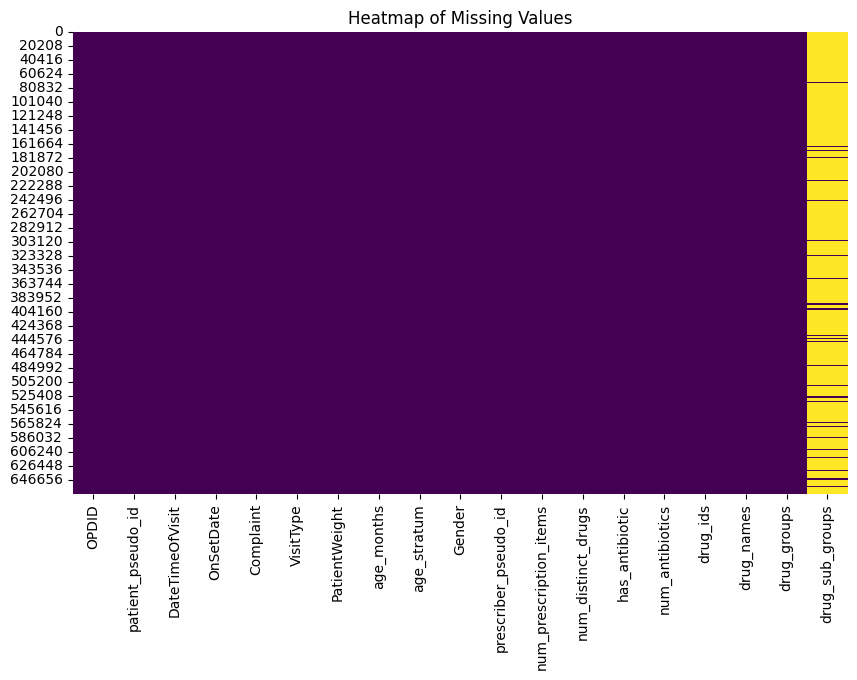

In [5]:
# heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')

In [6]:
df.drug_sub_groups.value_counts().head(20)

drug_sub_groups
|Electrolytes                                   40556
|Multivitamin                                    1423
Electrolytes                                     1011
|Iron                                             239
|Electrolytes|Serotonin Receptor Antagonists      176
Multivitamin                                      173
|Electrolytes|Multivitamin                        149
|Tricyclic antidepressants                        137
|Calcium channel blockers                         105
|Benzodiazepines                                   97
|Serotonin Receptor Antagonists                    56
|Anthelmintics                                     30
Iron                                               27
|Quinolone                                         26
|Vitamin D                                         26
Anticonvulsants                                    24
Anthelmintics                                      22
Electrolytes|Serotonin Receptor Antagonists        15
Tricyclic an

In [7]:
# drug subgroup values should be removed as it is not relevant to this clustering as it is
df.drop('drug_sub_groups', axis=1, inplace=True)

In [8]:
df.VisitType.value_counts()
# 9 - OPD, 14 - AS OPD
# drop all except 9

VisitType
9     653926
14     12837
11        59
13         9
Name: count, dtype: int64

In [9]:
# drop all except 9, then drop the VisitType column as it is not relevant to this clustering as it is
df = df[df['VisitType'] == 9]
df.drop('VisitType', axis=1, inplace=True)

In [10]:
# drop following columns - OnSetDate,num_prescription_items,drug_ids
df.drop(['OnSetDate', 'num_prescription_items', 'drug_ids'], axis=1, inplace=True)

In [11]:
df.head(2)

,OPDID,patient_pseudo_id,DateTimeOfVisit,Complaint,PatientWeight,age_months,age_stratum,Gender,prescriber_pseudo_id,num_distinct_drugs,has_antibiotic,num_antibiotics,drug_names,drug_groups
0,35264,4568a69a7836afa716a028dff73efa21d991463fd29144...,3/1/2023 7:16,cough,0.0,35,preschool_2_4y,Female,b5da42655880d43181303fbfadd2f9ef24eeb85fff509b...,5,1,1,"Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml|...",Analgesics|Antibiotics|Antihistamines|Bronchod...
1,35267,89f46a2fd97e08b46c3e009a4c4392ea9beed26d2bfb7b...,3/1/2023 7:21,c,0.0,144,adolescent_12_17y,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,2,1,1,Cephalexin 250 mg Caps|Chlorpheniramine (Pirit...,Antibiotics|Antihistamines


In [12]:
df.drug_names.value_counts()

drug_names
Amoxicillin 250 mg Caps|Chlorpheniramine (Piriton) tab.  4mg|Paracetamol tab. 500mg|Salbutamol tab. 2mg                                                                                                    16394
Amoxicillin 125mg/5ml Syrup|Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml|Paracetamol syr. 120mg/5ml, 60ml|Salbutamol syr. 2mg/5ml, 60ml                                                                   14801
Chlorpheniramine (Piriton) tab.  4mg|Salbutamol tab. 2mg|Theophylline SR tabs 125mg                                                                                                                        12510
Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml|Salbutamol syr. 2mg/5ml, 60ml                                                                                                                                12218
Chlorpheniramine (Piriton) tab.  4mg|Paracetamol tab. 500mg|Salbutamol tab. 2mg                                                                          

In [13]:
# Extract all unique drug names from the pipe-separated column

all_drugs = (
    df["drug_names"]
    .dropna()
    .str.split("|")           # split each row by pipe
    .explode()                # put each drug on its own row
    .str.strip()              # remove extra spaces
    .unique()                 # keep only unique names
)

# Sort alphabetically and print
all_drugs_sorted = sorted(all_drugs)

print(f"Total unique drugs: {len(all_drugs_sorted)}")
print("\n--- Full drug list ---")
for drug in all_drugs_sorted:
    print(drug)

Total unique drugs: 423

--- Full drug list ---
*Balanced salt solution 500ml
*Hydroxyethylcellulose 0.44% + Sodium Chloride 0.35%eye drop
0.05% Fluoride Mouth Wash,60-100 ml bot
0.2% Chlorhexidine Mouth Wash 100ml
Aciclovir Tab. 200mg
Aciclovir Tab. 800mg
Adapalene gel 0.1%, 45g
Albendazole syrup 200mg/5ml,30ml bottle
Alfa Calcidol  0.25mcg INACTIVE
Aluminium Hydroxide 500 mg
Amitriptyline tab. 10mg
Amitriptyline tab. 25mg
Amorolfine Cream 1% 15g
Amoxicillin 125 mg Tabs
Amoxicillin 125mg/5ml Syrup
Amoxicillin 250 mg Caps
Amoxicillin 500 mg
Aqueous Cream
Aspirin Enteric-coated Tab 75mg
Atorvastatin 10 mg Tab
Atorvastatin tab. 20mg
Atropine sulphate Eye Drops1% 5ml
Azithromycin 250mg Tab
Azithromycin dihydrate syrup 200mg/5ml 15ml
Baby mask for spacer device
Baclofen tab. 10mg
Baclofen tablet 5mg
Beclometasone Nasal Spray 100mcg/MD 120D
Beclomethasone 0.025% and Miconazole 2% Lotion 30mL Bottle
Beclomethasone DP Caps 200mcg
Beclomethasone Dipropionate MDI 250mcg
Beclomethasone MDI 100mc

In [14]:
df.head(3)

,OPDID,patient_pseudo_id,DateTimeOfVisit,Complaint,PatientWeight,age_months,age_stratum,Gender,prescriber_pseudo_id,num_distinct_drugs,has_antibiotic,num_antibiotics,drug_names,drug_groups
0,35264,4568a69a7836afa716a028dff73efa21d991463fd29144...,3/1/2023 7:16,cough,0.0,35,preschool_2_4y,Female,b5da42655880d43181303fbfadd2f9ef24eeb85fff509b...,5,1,1,"Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml|...",Analgesics|Antibiotics|Antihistamines|Bronchod...
1,35267,89f46a2fd97e08b46c3e009a4c4392ea9beed26d2bfb7b...,3/1/2023 7:21,c,0.0,144,adolescent_12_17y,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,2,1,1,Cephalexin 250 mg Caps|Chlorpheniramine (Pirit...,Antibiotics|Antihistamines
2,35268,d9610fe238c741ec4e8408c4b3c9ced8c6b87a3a457529...,3/1/2023 7:23,c,0.0,18,toddler_12_23m,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,3,1,1,Amoxicillin 125 mg Tabs|Chlorpheniramine (Piri...,Analgesics|Antibiotics|Antihistamines


In [15]:
df.columns

Index(['OPDID', 'patient_pseudo_id', 'DateTimeOfVisit', 'Complaint',
       'PatientWeight', 'age_months', 'age_stratum', 'Gender',
       'prescriber_pseudo_id', 'num_distinct_drugs', 'has_antibiotic',
       'num_antibiotics', 'drug_names', 'drug_groups'],
      dtype='str')

In [16]:
import importlib
import aware_enrichment           # your existing import

importlib.reload(aware_enrichment)   # forces Python to re-read the file

from aware_enrichment import check_unmatched_drugs, enrich_dataframe

In [17]:
#from aware_enrichment import check_unmatched_drugs, enrich_dataframe

# Step 1 — check for name mismatches first
check_unmatched_drugs(df)



Checking lookup coverage against your data...

  Encounters with antibiotics (has_antibiotic=1) : 319454
  Encounters fully covered by our lookup         : 316877
  Encounters with at least one missed antibiotic : 2577
  Coverage                                       : 99.2%

  No obvious missed antibiotics in the unmatched list.

  Non-antibiotic companion drugs (do NOT add — these appear
  alongside truly missed antibiotics in the same encounter):
  81 drugs filtered  (total appearances: 10371)
  Examples: Chlorpheniramine (Piriton) tab.  4mg, Paracetamol tab. 500mg, Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml, Normal Saline Nasal Drops ...


{'Chlorpheniramine (Piriton) tab.  4mg': 1410,
 'Paracetamol tab. 500mg': 1163,
 'Chlorpheniramine (Piriton) syr. 2mg/5ml, 60ml': 1294,
 'Normal Saline Nasal Drops': 426,
 'Paracetamol syr. 120mg/5ml, 60ml': 987,
 'prednisoLONE 5mg Tab': 930,
 'Salbutamol syr. 2mg/5ml, 60ml': 917,
 'Domperidone 10mg Tabs': 246,
 'Domperidone Sy. 5mg/5ml 100ml': 129,
 'Salbutamol tab. 2mg': 1110,
 'Salbutamol 4 mg': 4,
 'Vitamin C 50 mg': 74,
 'Vitamin C tab. 100mg': 131,
 'Famotidine 20 mg Tab': 145,
 'Omeprazole tablet 10mg': 38,
 'Promethazine HCL tab. 10mg': 6,
 '*Balanced salt solution 500ml': 1,
 'Ibuprofen Tabs 200mg': 16,
 'Paraffin Liquid': 1,
 'Hydrocortisone Skin Cream  1% 5 g': 35,
 'Pyrantel Pamoate oral suspnsion 50mg/ml': 4,
 'Multivitamin Drops 15ml (Grovit)': 2,
 'Oral Rehydration Powder Sachet (Jeewani) 200ml': 108,
 'Oral Rehydration Solution (Jeewani)': 28,
 'Diclofenac Sodium 25 mg SR tablet': 5,
 'Calamine lotion': 1,
 'Hydrocortisone Skin Ointment 1% 5 g': 4,
 'Mebendazole 100mg':

In [18]:
# Step 2 — if checker is happy, enrich
df = enrich_dataframe(df)

Starting AWaRe enrichment...
  Total encounters : 653926

  Enrichment complete. Columns added:
     - aware_categories
     - aware_profile
     - has_watch_antibiotic
     - has_broad_spectrum
     - antibiotic_groups
     - class_profile
     - antibiotic_routes
     - spectrum_profile
     - antibiotic_compounds
     - route_profile

  aware_profile distribution:
aware_profile
No antibiotic     312021
Access-only       259375
Watch-only         33669
Not classified     24976
Mixed              23885

  route_profile distribution (antibiotic encounters only):
route_profile
Oral          315005
Topical         4440
Parenteral         9


In [19]:
df.head(3)

,OPDID,patient_pseudo_id,DateTimeOfVisit,Complaint,PatientWeight,age_months,age_stratum,Gender,prescriber_pseudo_id,num_distinct_drugs,...,aware_categories,aware_profile,has_watch_antibiotic,has_broad_spectrum,antibiotic_groups,class_profile,antibiotic_routes,spectrum_profile,antibiotic_compounds,route_profile
0,35264,4568a69a7836afa716a028dff73efa21d991463fd29144...,3/1/2023 7:16,cough,0.0,35,preschool_2_4y,Female,b5da42655880d43181303fbfadd2f9ef24eeb85fff509b...,5,...,Access,Access-only,0,1,Aminopenicillin + BLI,Aminopenicillin + BLI,Oral,Broad,Amoxicillin + Clavulanate,Oral
1,35267,89f46a2fd97e08b46c3e009a4c4392ea9beed26d2bfb7b...,3/1/2023 7:21,c,0.0,144,adolescent_12_17y,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,2,...,Access,Access-only,0,0,1st Gen. Cephalosporin,1st Gen. Cephalosporin,Oral,Narrow-Moderate,Cephalexin,Oral
2,35268,d9610fe238c741ec4e8408c4b3c9ced8c6b87a3a457529...,3/1/2023 7:23,c,0.0,18,toddler_12_23m,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,3,...,Access,Access-only,0,0,Aminopenicillin,Aminopenicillin,Oral,Narrow-Moderate,Amoxicillin,Oral


In [20]:
df.columns

Index(['OPDID', 'patient_pseudo_id', 'DateTimeOfVisit', 'Complaint',
       'PatientWeight', 'age_months', 'age_stratum', 'Gender',
       'prescriber_pseudo_id', 'num_distinct_drugs', 'has_antibiotic',
       'num_antibiotics', 'drug_names', 'drug_groups', 'aware_categories',
       'aware_profile', 'has_watch_antibiotic', 'has_broad_spectrum',
       'antibiotic_groups', 'class_profile', 'antibiotic_routes',
       'spectrum_profile', 'antibiotic_compounds', 'route_profile'],
      dtype='str')

In [21]:
#all_complaints = df['Complaint']
#all_complaints.to_csv('all_complaints_2.csv', index=False)

In [22]:
import sys
sys.path.insert(0, r'd:\Academic\MD Research 2025\AMS_2026')
from complaint_cleaning import add_complaint_features, add_symptom_features

df = add_complaint_features(df)   # creates complaint_clean, complaint_category, complaint_duration_days
df = add_symptom_features(df)     # creates symptom_tags, symptom_profile, has_fever, has_respiratory

Adding complaint features...
  Total encounters : 653,926

  complaint_category distribution:
complaint_category
Respiratory-URTI      295535
Multi-system          126147
Fever                  84962
Skin                   51137
GI                     33667
Unclassified           31397
ENT                    12846
Respiratory-Wheeze     11794
Neuro                   3521
UTI                     1628
Musculo                 1163
Respiratory-LRTI         129

  Classified    : 622,529 (95.2%)
  Unclassified  : 31,397 (4.8%)
  With duration : 123,622 (18.9%)
Adding symptom features...

  symptom_profile distribution:
symptom_profile
Respiratory-URTI        295535
Fever                    84962
Fever+Respiratory        76686
Skin                     51137
GI                       33667
Unclassified             31397
ENT                      12846
Fever+GI                 12123
Respiratory-Wheeze       11794
Fever+Respiratory+GI      5641
Respiratory+Skin          4878
Respiratory+ENT      

In [23]:
df.columns

Index(['OPDID', 'patient_pseudo_id', 'DateTimeOfVisit', 'Complaint',
       'PatientWeight', 'age_months', 'age_stratum', 'Gender',
       'prescriber_pseudo_id', 'num_distinct_drugs', 'has_antibiotic',
       'num_antibiotics', 'drug_names', 'drug_groups', 'aware_categories',
       'aware_profile', 'has_watch_antibiotic', 'has_broad_spectrum',
       'antibiotic_groups', 'class_profile', 'antibiotic_routes',
       'spectrum_profile', 'antibiotic_compounds', 'route_profile',
       'complaint_clean', 'complaint_category', 'complaint_duration_days',
       'symptom_tags', 'symptom_profile', 'has_fever', 'has_respiratory'],
      dtype='str')

In [24]:
df.complaint_clean.value_counts().head(50)

complaint_clean
cough                                      219113
fever                                       73758
cough cold                                  37502
fever cough                                 30040
cough fever                                 11791
rash                                        11077
rash localized                               9616
cold                                         6513
abdominal pain                               5968
cough cold fever                             5889
fever cough cold                             5780
vomiting                                     5135
acute nasopharyngitis common cold            4434
wheezing                                     3919
scabies other acariasis                      3350
diarrhoea                                    3272
skin                                         2710
headache                                     2583
fever vomiting                               2456
fever cold                        

In [25]:
# add temporal features
from temporal_features import add_temporal_features
df = add_temporal_features(df)

Adding temporal features...
  Total encounters : 653,926
  Datetime parsed  : 653,926 (100.0%)

  visit_month distribution:
visit_month
1     52942
2     39158
3     55779
4     48309
5     57954
6     60411
7     64805
8     51955
9     49480
10    63580
11    56149
12    53404

  visit_hour distribution:
visit_hour
0      1317
1       780
2       528
3       467
4       455
5       717
6      2863
7     20931
8     44942
9     64516
10    83980
11    75660
12    67131
13    53401
14    47807
15    41323
16    29846
17    27685
18    23474
19    23730
20    20348
21    12429
22     6680
23     2916


In [26]:
df.head(3)

,OPDID,patient_pseudo_id,DateTimeOfVisit,Complaint,PatientWeight,age_months,age_stratum,Gender,prescriber_pseudo_id,num_distinct_drugs,...,route_profile,complaint_clean,complaint_category,complaint_duration_days,symptom_tags,symptom_profile,has_fever,has_respiratory,visit_month,visit_hour
0,35264,4568a69a7836afa716a028dff73efa21d991463fd29144...,2023-03-01 07:16:00,cough,0.0,35,preschool_2_4y,Female,b5da42655880d43181303fbfadd2f9ef24eeb85fff509b...,5,...,Oral,cough,Respiratory-URTI,NaN,Respiratory-URTI,Respiratory-URTI,0,1,3,7
1,35267,89f46a2fd97e08b46c3e009a4c4392ea9beed26d2bfb7b...,2023-03-01 07:21:00,c,0.0,144,adolescent_12_17y,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,2,...,Oral,cough,Respiratory-URTI,NaN,Respiratory-URTI,Respiratory-URTI,0,1,3,7
2,35268,d9610fe238c741ec4e8408c4b3c9ced8c6b87a3a457529...,2023-03-01 07:23:00,c,0.0,18,toddler_12_23m,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,3,...,Oral,cough,Respiratory-URTI,NaN,Respiratory-URTI,Respiratory-URTI,0,1,3,7


In [27]:
df.columns

Index(['OPDID', 'patient_pseudo_id', 'DateTimeOfVisit', 'Complaint',
       'PatientWeight', 'age_months', 'age_stratum', 'Gender',
       'prescriber_pseudo_id', 'num_distinct_drugs', 'has_antibiotic',
       'num_antibiotics', 'drug_names', 'drug_groups', 'aware_categories',
       'aware_profile', 'has_watch_antibiotic', 'has_broad_spectrum',
       'antibiotic_groups', 'class_profile', 'antibiotic_routes',
       'spectrum_profile', 'antibiotic_compounds', 'route_profile',
       'complaint_clean', 'complaint_category', 'complaint_duration_days',
       'symptom_tags', 'symptom_profile', 'has_fever', 'has_respiratory',
       'visit_month', 'visit_hour'],
      dtype='str')

In [33]:
df['class_profile'].head(20)

0          Aminopenicillin + BLI
1         1st Gen. Cephalosporin
2                Aminopenicillin
3                  No antibiotic
4                Aminopenicillin
5                  No antibiotic
6         1st Gen. Cephalosporin
7                  No antibiotic
8     Aminopenicillin/Antifungal
9                Aminopenicillin
10               Aminopenicillin
11               Aminopenicillin
12               Aminopenicillin
13               Aminopenicillin
14               Aminopenicillin
15                 No antibiotic
16               Aminopenicillin
17               Aminopenicillin
18         Aminopenicillin + BLI
19                 No antibiotic
Name: class_profile, dtype: str

In [34]:
df.head(3)

,OPDID,patient_pseudo_id,DateTimeOfVisit,Complaint,PatientWeight,age_months,age_stratum,Gender,prescriber_pseudo_id,num_distinct_drugs,...,route_profile,complaint_clean,complaint_category,complaint_duration_days,symptom_tags,symptom_profile,has_fever,has_respiratory,visit_month,visit_hour
0,35264,4568a69a7836afa716a028dff73efa21d991463fd29144...,2023-03-01 07:16:00,cough,0.0,35,preschool_2_4y,Female,b5da42655880d43181303fbfadd2f9ef24eeb85fff509b...,5,...,Oral,cough,Respiratory-URTI,NaN,Respiratory-URTI,Respiratory-URTI,0,1,3,7
1,35267,89f46a2fd97e08b46c3e009a4c4392ea9beed26d2bfb7b...,2023-03-01 07:21:00,c,0.0,144,adolescent_12_17y,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,2,...,Oral,cough,Respiratory-URTI,NaN,Respiratory-URTI,Respiratory-URTI,0,1,3,7
2,35268,d9610fe238c741ec4e8408c4b3c9ced8c6b87a3a457529...,2023-03-01 07:23:00,c,0.0,18,toddler_12_23m,Female,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1a74af53e4b...,3,...,Oral,cough,Respiratory-URTI,NaN,Respiratory-URTI,Respiratory-URTI,0,1,3,7
